# Phase 1: Data Cleaning and Preparation
### Part A: Load data and do initial inspection

In [1]:
import pandas as pd

In [2]:
# Load the dataset
file_path = "Electric_Vehicle_Population.csv"
df = pd.read_csv(file_path)

In [3]:
# 1. Basic shape and structure of the data
print("Shape of dataset (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset (rows, columns): (177866, 17)

Column names:
['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Base MSRP', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']


In [4]:
# 2. Data types of each column
print("\nData types:")
print(df.dtypes)


Data types:
VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                         int64
Base MSRP                                              int64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Census

In [5]:
# 3. First few rows to eyeball the data
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   VIN (1-10)     County       City State  Postal Code  Model Year   Make  \
0  5YJYGDEE1L       King    Seattle    WA      98122.0        2020  TESLA   
1  7SAYGDEE9P  Snohomish    Bothell    WA      98021.0        2023  TESLA   
2  5YJSA1E4XK       King    Seattle    WA      98109.0        2019  TESLA   
3  5YJSA1E27G       King   Issaquah    WA      98027.0        2016  TESLA   
4  5YJYGDEE5M     Kitsap  Suquamish    WA      98392.0        2021  TESLA   

     Model           Electric Vehicle Type  \
0  MODEL Y  Battery Electric Vehicle (BEV)   
1  MODEL Y  Battery Electric Vehicle (BEV)   
2  MODEL S  Battery Electric Vehicle (BEV)   
3  MODEL S  Battery Electric Vehicle (BEV)   
4  MODEL Y  Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0            Clean Alternative Fuel Vehicle Eligible             291   
1  Eligibility unknown as battery range has not b...               0   
2            Clean Alternativ

In [6]:
# 4. Check for missing values in each column
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
VIN (1-10)                                             0
County                                                 5
City                                                   5
State                                                  0
Postal Code                                            5
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 389
DOL Vehicle ID                                         0
Vehicle Location                                       9
Electric Utility                                       5
2020 Census Tract                                      5
dty

In [7]:
# 5. Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


### Part B: Investigate and clean

In [8]:
# Confirm if the 5 missing rows overlap across columns 
missing_rows = df[df['County'].isnull()]
print("Rows with missing County (checking if same rows are missing elsewhere too):")
print(missing_rows[['County', 'City', 'Postal Code', 'Electric Utility', '2020 Census Tract']])


Rows with missing County (checking if same rows are missing elsewhere too):
       County City  Postal Code Electric Utility  2020 Census Tract
149245    NaN  NaN          NaN              NaN                NaN
154553    NaN  NaN          NaN              NaN                NaN
159157    NaN  NaN          NaN              NaN                NaN
167298    NaN  NaN          NaN              NaN                NaN
170413    NaN  NaN          NaN              NaN                NaN


In [9]:
# Check how many rows have Electric Range = 0 (likely "unknown", not truly zero) 
zero_range_count = (df['Electric Range'] == 0).sum()
print(f"\nRows where Electric Range = 0: {zero_range_count} out of {len(df)}")


Rows where Electric Range = 0: 91950 out of 177866


In [10]:
# Check how many rows have Base MSRP = 0
zero_msrp_count = (df['Base MSRP'] == 0).sum()
print(f"Rows where Base MSRP = 0: {zero_msrp_count} out of {len(df)}")

Rows where Base MSRP = 0: 174522 out of 177866


### Part C: Apply the cleaning decisions

In [11]:
#Drop the 5 rows with completely missing geo/location data
df_clean = df.dropna(subset=['County', 'City', 'Postal Code']).copy()
print("Shape after dropping 5 incomplete rows:", df_clean.shape)

Shape after dropping 5 incomplete rows: (177861, 17)


In [12]:
# Handle Legislative District missing values 
df_clean['Legislative District'] = df_clean['Legislative District'].fillna('Unknown')

In [13]:
#Flag Electric Range = 0 as "Unknown" instead of treating as real zero 
df_clean['Range Reported'] = df_clean['Electric Range'].apply(
    lambda x: 'Unknown' if x == 0 else 'Reported')

In [14]:
#Flag Base MSRP as unreliable
msrp_missing_pct = (df_clean['Base MSRP'] == 0).mean() * 100
print(f"\nBase MSRP is 0 for {msrp_missing_pct:.1f}% of rows — excluding from stats analysis.")



Base MSRP is 0 for 98.1% of rows — excluding from stats analysis.


In [15]:
# Parse 'Vehicle Location' into Latitude and Longitude columns

def extract_coordinates(location):
    if pd.isnull(location):
        return pd.Series([None, None])
    try:
        coords = location.replace('POINT (', '').replace(')', '').split(' ')
        longitude = float(coords[0])
        latitude = float(coords[1])
        return pd.Series([latitude, longitude])
    except:
        return pd.Series([None, None])

df_clean[['Latitude', 'Longitude']] = df_clean['Vehicle Location'].apply(extract_coordinates)

print("\nMissing Latitude/Longitude after parsing:", df_clean['Latitude'].isnull().sum())


Missing Latitude/Longitude after parsing: 4


In [16]:
print("\nFinal shape of cleaned dataset:", df_clean.shape)
print("\nMissing values remaining:")
print(df_clean.isnull().sum())


Final shape of cleaned dataset: (177861, 20)

Missing values remaining:
VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
Legislative District                                 0
DOL Vehicle ID                                       0
Vehicle Location                                     4
Electric Utility                                     0
2020 Census Tract                              

In [17]:
# Save the cleaned dataset to a new CSV
df_clean.to_csv("ev_data_cleaned.csv", index=False)
print("Cleaned dataset saved as 'ev_data_cleaned.csv'")
print("Final shape:", df_clean.shape)

Cleaned dataset saved as 'ev_data_cleaned.csv'
Final shape: (177861, 20)


# Phase 2: Descriptive Analysis
### Part A: Summary statistics

In [18]:
df_clean = pd.read_csv("ev_data_cleaned.csv")

C:\Users\vaibh\AppData\Local\Temp\ipykernel_6324\1791785855.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("ev_data_cleaned.csv")


In [19]:
#Electric Range stats
reported_range = df_clean[df_clean['Range Reported'] == 'Reported']['Electric Range']

print("=== Electric Range Summary (Reported values only) ===")
print(f"Count      : {reported_range.count()}")
print(f"Mean       : {reported_range.mean():.2f} miles")
print(f"Median     : {reported_range.median():.2f} miles")
print(f"Std Dev    : {reported_range.std():.2f}")
print(f"Min        : {reported_range.min()}")
print(f"Max        : {reported_range.max()}")

=== Electric Range Summary (Reported values only) ===
Count      : 85911
Mean       : 121.81 miles
Median     : 84.00 miles
Std Dev    : 99.22
Min        : 6
Max        : 337


In [20]:
#Base MSRP stats
print("\n=== Base MSRP Summary (includes unreliable zeros — for reference only) ===")
print(df_clean['Base MSRP'].describe())


=== Base MSRP Summary (includes unreliable zeros — for reference only) ===
count    177861.000000
mean       1072.583197
std        8355.518364
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      845000.000000
Name: Base MSRP, dtype: float64


In [21]:
# For comparison, checking MSRP stats excluding the zeros
nonzero_msrp = df_clean[df_clean['Base MSRP'] > 0]['Base MSRP']
print(f"\nRows with non-zero MSRP: {len(nonzero_msrp)} out of {len(df_clean)}")
if len(nonzero_msrp) > 0:
    print(f"Mean (non-zero only)   : {nonzero_msrp.mean():.2f}")
    print(f"Median (non-zero only) : {nonzero_msrp.median():.2f}")


Rows with non-zero MSRP: 3343 out of 177861
Mean (non-zero only)   : 57065.73
Median (non-zero only) : 59900.00


In [22]:
# Model Year distribution 
print("\n=== Model Year Summary ===")
print(df_clean['Model Year'].describe())


=== Model Year Summary ===
count    177861.000000
mean       2020.515667
std           2.989206
min        1997.000000
25%        2019.000000
50%        2022.000000
75%        2023.000000
max        2024.000000
Name: Model Year, dtype: float64


### Part B: Visualizations

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
sns.set_style("whitegrid")

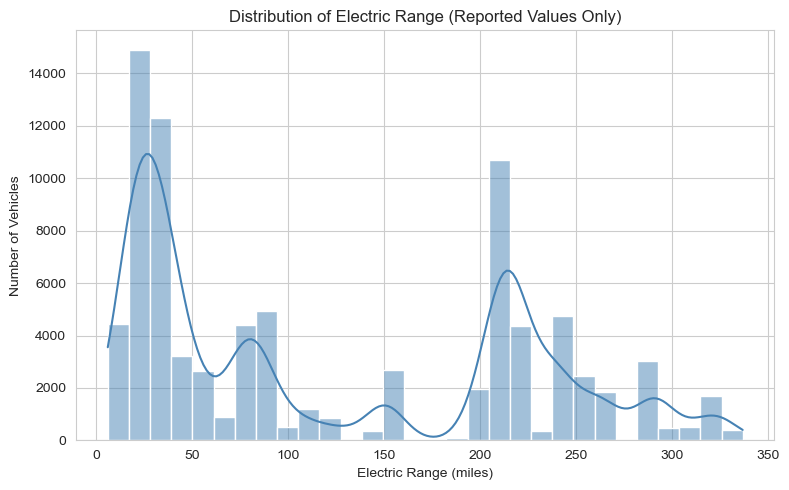

In [25]:
# Histogram of Electric Range
plt.figure(figsize=(8, 5))
sns.histplot(reported_range, bins=30, color='steelblue', kde=True)
plt.title("Distribution of Electric Range (Reported Values Only)")
plt.xlabel("Electric Range (miles)")
plt.ylabel("Number of Vehicles")
plt.tight_layout()
plt.savefig("electric_range_histogram.png")
plt.show()

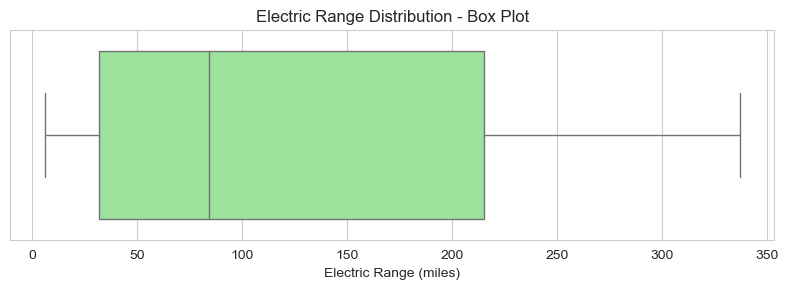

In [26]:
#Box plot of Electric Range-
plt.figure(figsize=(8, 3))
sns.boxplot(x=reported_range, color='lightgreen')
plt.title("Electric Range Distribution - Box Plot")
plt.xlabel("Electric Range (miles)")
plt.tight_layout()
plt.savefig("electric_range_boxplot.png")
plt.show()

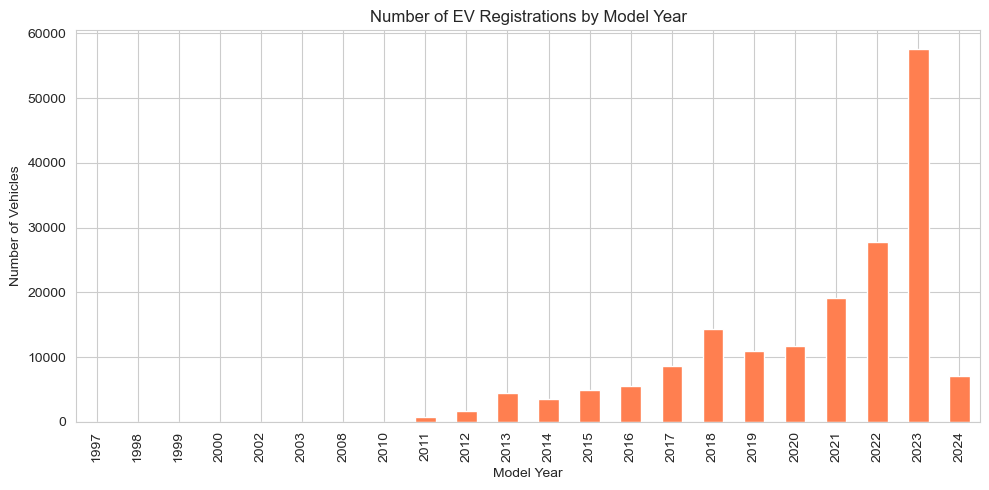

In [27]:
# Model Year distribution (bar chart)
plt.figure(figsize=(10, 5))
model_year_counts = df_clean['Model Year'].value_counts().sort_index()
model_year_counts.plot(kind='bar', color='coral')
plt.title("Number of EV Registrations by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")
plt.tight_layout()
plt.savefig("model_year_distribution.png")
plt.show()

# Phase 3: Time-Series Analysis
### Part A: Yearly trend + YoY growth rate

In [28]:
#Registrations per Model Year 
yearly_counts = df_clean['Model Year'].value_counts().sort_index()
yearly_df = yearly_counts.reset_index()
yearly_df.columns = ['Model Year', 'Registrations']
print("Registrations by Model Year:")
print(yearly_df)

Registrations by Model Year:
    Model Year  Registrations
0         1997              1
1         1998              1
2         1999              5
3         2000              7
4         2002              2
5         2003              1
6         2008             19
7         2010             23
8         2011            775
9         2012           1618
10        2013           4408
11        2014           3509
12        2015           4844
13        2016           5483
14        2017           8561
15        2018          14322
16        2019          10939
17        2020          11768
18        2021          19132
19        2022          27776
20        2023          57587
21        2024           7080


In [29]:
# Year-over-Year (YoY) growth rate
yearly_df['YoY Growth (%)'] = yearly_df['Registrations'].pct_change() * 100
print("\nYear-over-Year Growth Rate:")
print(yearly_df)


Year-over-Year Growth Rate:
    Model Year  Registrations  YoY Growth (%)
0         1997              1             NaN
1         1998              1        0.000000
2         1999              5      400.000000
3         2000              7       40.000000
4         2002              2      -71.428571
5         2003              1      -50.000000
6         2008             19     1800.000000
7         2010             23       21.052632
8         2011            775     3269.565217
9         2012           1618      108.774194
10        2013           4408      172.435105
11        2014           3509      -20.394737
12        2015           4844       38.045027
13        2016           5483       13.191577
14        2017           8561       56.137151
15        2018          14322       67.293540
16        2019          10939      -23.621003
17        2020          11768        7.578389
18        2021          19132       62.576479
19        2022          27776       45.180849
20   

In [30]:
# Cumulative registrations over time (running total = market size so far)
yearly_df['Cumulative Registrations'] = yearly_df['Registrations'].cumsum()

print("\nWith Cumulative Registrations:")
print(yearly_df)


With Cumulative Registrations:
    Model Year  Registrations  YoY Growth (%)  Cumulative Registrations
0         1997              1             NaN                         1
1         1998              1        0.000000                         2
2         1999              5      400.000000                         7
3         2000              7       40.000000                        14
4         2002              2      -71.428571                        16
5         2003              1      -50.000000                        17
6         2008             19     1800.000000                        36
7         2010             23       21.052632                        59
8         2011            775     3269.565217                       834
9         2012           1618      108.774194                      2452
10        2013           4408      172.435105                      6860
11        2014           3509      -20.394737                     10369
12        2015           4844   

### Part B: Visualizations

In [31]:
#plot after 2011 onward for clear visuals
plot_df = yearly_df[yearly_df['Model Year'] >= 2011].copy()

In [32]:
# Registrations per year (line chart)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(plot_df['Model Year'], plot_df['Registrations'], marker='o', color='steelblue', label="Registrations")

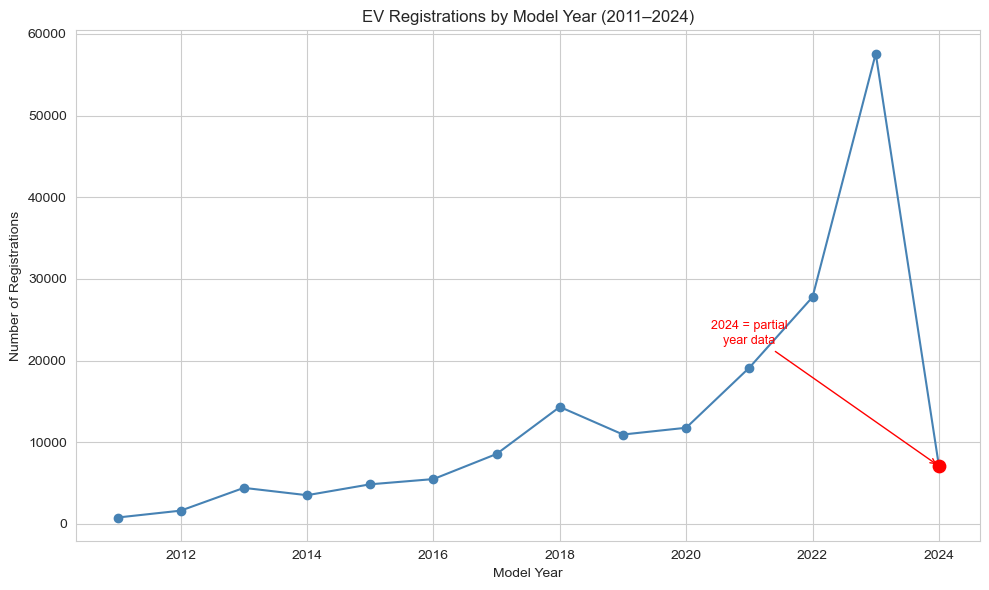

In [33]:
# 2024 point
last_row = plot_df[plot_df['Model Year'] == 2024]
if not last_row.empty:
    x_val = last_row['Model Year'].values[0]
    y_val = last_row['Registrations'].values[0]
    ax.scatter(x_val, y_val, color='red', zorder=5, s=80)
    ax.annotate('2024 = partial\nyear data',
                xy=(x_val, y_val),
                xytext=(x_val - 3, y_val + 15000),
                arrowprops=dict(arrowstyle='->', color='red'),
                color='red', fontsize=9, ha='center')

ax.set_title("EV Registrations by Model Year (2011–2024)")
ax.set_xlabel("Model Year")
ax.set_ylabel("Number of Registrations")
plt.tight_layout()
plt.savefig("registrations_timeseries.png")
plt.show()

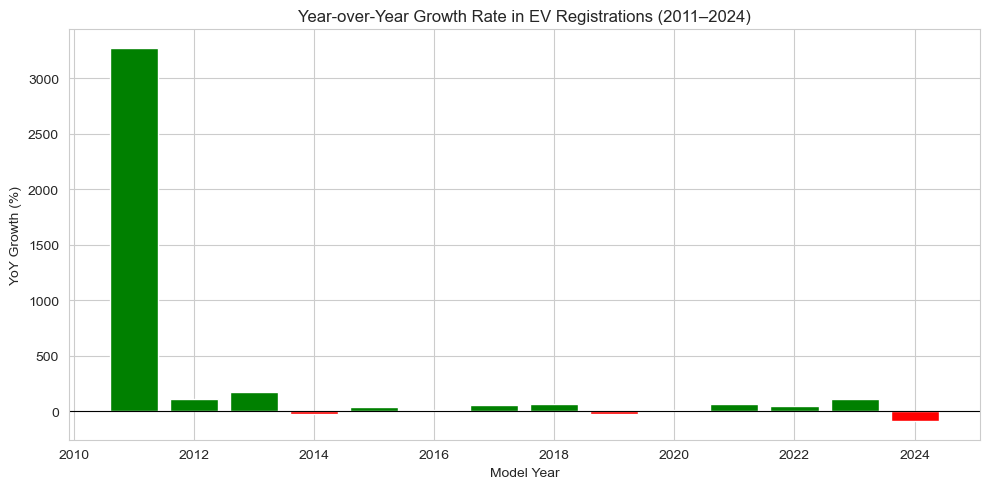

In [34]:
# YoY Growth Rate 
plt.figure(figsize=(10, 5))
colors = ['green' if x >= 0 else 'red' for x in plot_df['YoY Growth (%)']]
plt.bar(plot_df['Model Year'], plot_df['YoY Growth (%)'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Year-over-Year Growth Rate in EV Registrations (2011–2024)")
plt.xlabel("Model Year")
plt.ylabel("YoY Growth (%)")
plt.tight_layout()
plt.savefig("yoy_growth.png")
plt.show()

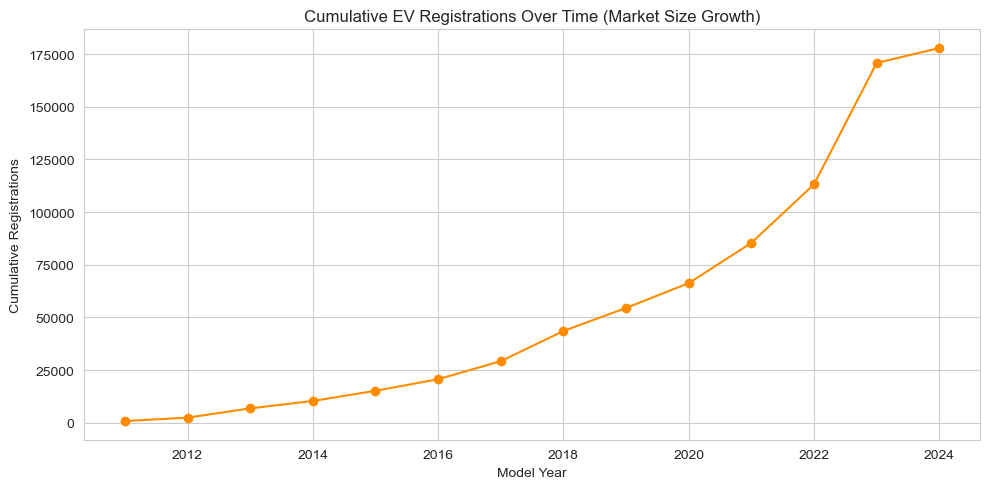

In [35]:
#Cumulative registrations
plt.figure(figsize=(10, 5))
plt.plot(plot_df['Model Year'], plot_df['Cumulative Registrations'], marker='o', color='darkorange')
plt.title("Cumulative EV Registrations Over Time (Market Size Growth)")
plt.xlabel("Model Year")
plt.ylabel("Cumulative Registrations")
plt.tight_layout()
plt.savefig("cumulative_registrations.png")
plt.show()

# Phase 4: Geographical Distribution Analysis
### Part A: County and City breakdown

In [36]:
print("State value counts:")
print(df_clean['State'].value_counts())

State value counts:
State
WA    177477
CA       101
VA        46
MD        31
TX        23
NC        16
IL        15
CO        12
AZ        10
FL        10
HI         9
NJ         8
NV         8
NY         7
SC         7
CT         6
GA         6
AL         6
MA         5
OR         5
MO         5
PA         4
LA         4
OH         4
DC         3
KY         3
IN         3
ID         3
UT         3
NE         2
KS         2
RI         2
WY         2
MN         2
MI         2
AR         2
DE         1
NH         1
OK         1
AK         1
IA         1
TN         1
NM         1
Name: count, dtype: int64


In [37]:
#Top 15 counties by registration count 
top_counties = df_clean['County'].value_counts().head(15)
print("\nTop 15 Counties by EV Registrations:")
print(top_counties)


Top 15 Counties by EV Registrations:
County
King         92740
Snohomish    21001
Pierce       13782
Clark        10416
Thurston      6428
Kitsap        5840
Spokane       4586
Whatcom       4253
Benton        2147
Skagit        1910
Island        1882
Clallam       1058
Chelan        1047
Yakima         995
Jefferson      977
Name: count, dtype: int64


In [38]:
#Top 15 cities by registration count
top_cities = df_clean['City'].value_counts().head(15)
print("\nTop 15 Cities by EV Registrations:")
print(top_cities)


Top 15 Cities by EV Registrations:
City
Seattle       29447
Bellevue       8931
Redmond        6478
Vancouver      6193
Bothell        5863
Kirkland       5362
Sammamish      5280
Renton         4980
Olympia        4299
Tacoma         3722
Bellingham     2941
Tukwila        2927
Kent           2782
Issaquah       2764
Spokane        2735
Name: count, dtype: int64


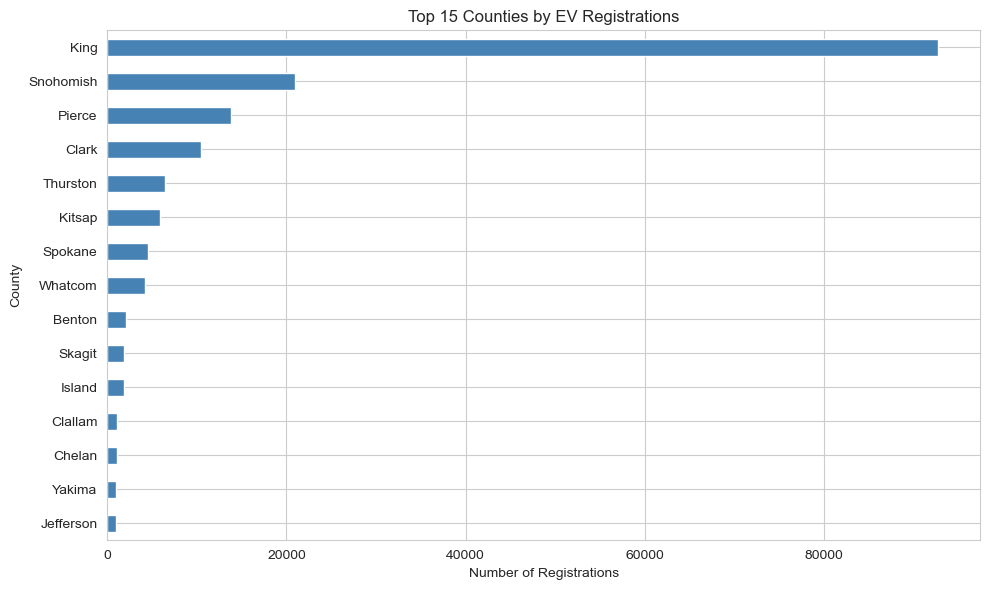

In [39]:
#Visualize top counties
plt.figure(figsize=(10, 6))
top_counties.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 15 Counties by EV Registrations")
plt.xlabel("Number of Registrations")
plt.ylabel("County")
plt.tight_layout()
plt.savefig("top_counties.png")
plt.show()

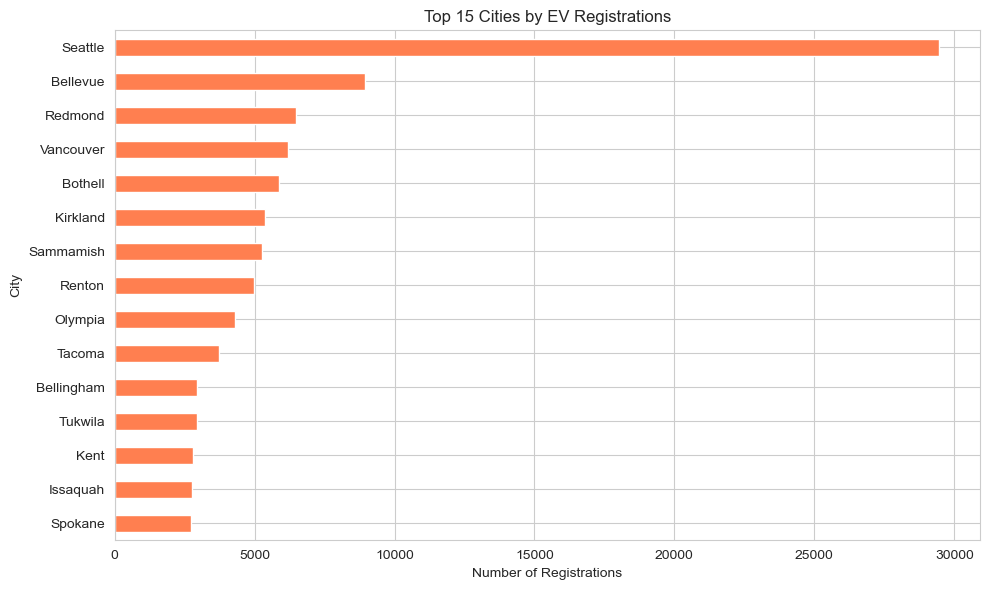

In [40]:
#Visualize top cities 
plt.figure(figsize=(10, 6))
top_cities.sort_values().plot(kind='barh', color='coral')
plt.title("Top 15 Cities by EV Registrations")
plt.xlabel("Number of Registrations")
plt.ylabel("City")
plt.tight_layout()
plt.savefig("top_cities.png")
plt.show()

In [41]:
# Filter to Washington only for all remaining geographic/spatial work
df_wa = df_clean[df_clean['State'] == 'WA'].copy()
print("Rows before filtering:", len(df_clean))
print("Rows after filtering to WA only:", len(df_wa))

Rows before filtering: 177861
Rows after filtering to WA only: 177477


In [42]:
# Save WA-only subset separately
df_wa.to_csv("ev_data_wa_only.csv", index=False)
print("Saved WA-only dataset as 'ev_data_wa_only.csv'")

Saved WA-only dataset as 'ev_data_wa_only.csv'


### Part B: Folium Heatmap

In [43]:
import folium
from folium.plugins import HeatMap

In [44]:
df_wa = pd.read_csv("ev_data_wa_only.csv")

In [45]:
# Drop rows with missing coordinates
df_map = df_wa.dropna(subset=['Latitude', 'Longitude']).copy()
print(f"Rows usable for mapping: {len(df_map)} out of {len(df_wa)}")

Rows usable for mapping: 177473 out of 177477


In [46]:
# base map centered roughly on Washington state
wa_map = folium.Map(location=[47.4, -120.7], zoom_start=7)

In [47]:
# data in: list of [lat, lon] pairs
heat_data = df_map[['Latitude', 'Longitude']].values.tolist()

# heatmap layer
HeatMap(heat_data, radius=8, blur=6).add_to(wa_map)

In [48]:
# map as an HTML file
wa_map.save("ev_heatmap_washington.html")
print("Heatmap saved as 'ev_heatmap_washington.html' — open this in your browser to view it")

Heatmap saved as 'ev_heatmap_washington.html' — open this in your browser to view it


### Part B: KMeans Clustering

In [49]:
from sklearn.cluster import KMeans

In [50]:
coords = df_map[['Latitude', 'Longitude']]
n_clusters = 6

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_map['Cluster'] = kmeans.fit_predict(coords)

print("Number of vehicles per cluster:")
print(df_map['Cluster'].value_counts().sort_index())

# Cluster centers = approximate hotspot locations
cluster_centers = kmeans.cluster_centers_
print("\nCluster centers (Latitude, Longitude):")
for i, center in enumerate(cluster_centers):
    print(f"Cluster {i}: Lat={center[0]:.4f}, Lon={center[1]:.4f}")

C:\Users\vaibh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\vaibh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\vaibh\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vaibh\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Number of vehicles per cluster:
Cluster
0    118938
1      5383
2      6979
3     11835
4     10740
5     23598
Name: count, dtype: int64

Cluster centers (Latitude, Longitude):
Cluster 0: Lat=47.6390, Lon=-122.2243
Cluster 1: Lat=47.6239, Lon=-117.3774
Cluster 2: Lat=46.7634, Lon=-119.7356
Cluster 3: Lat=45.7129, Lon=-122.5626
Cluster 4: Lat=48.5081, Lon=-122.6296
Cluster 5: Lat=47.1675, Lon=-122.6595


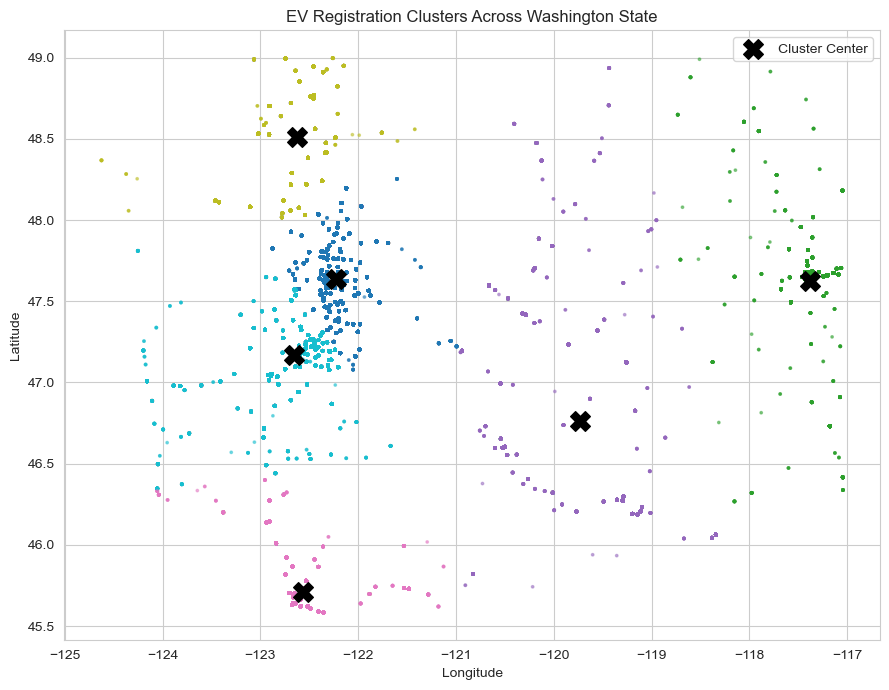

In [51]:
# clusters on a scatter plot ---
plt.figure(figsize=(9, 7))
scatter = plt.scatter(df_map['Longitude'], df_map['Latitude'],
                       c=df_map['Cluster'], cmap='tab10', s=3, alpha=0.5)
plt.scatter(cluster_centers[:, 1], cluster_centers[:, 0],
            color='black', marker='X', s=200, label='Cluster Center')
plt.title("EV Registration Clusters Across Washington State")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.savefig("ev_clusters_scatter.png")
plt.show()

# Phase 5: Make and Model Popularity
### Part A: Top Makes and Models

In [52]:
# Top 10 Makes
top_makes = df_wa['Make'].value_counts().head(10)
print("Top 10 Makes by Registration Count:")
print(top_makes)

Top 10 Makes by Registration Count:
Make
TESLA         79471
NISSAN        13984
CHEVROLET     13652
FORD           9177
BMW            7556
KIA            7423
TOYOTA         6255
VOLKSWAGEN     4993
JEEP           4469
HYUNDAI        4399
Name: count, dtype: int64


In [53]:
# Top 15 Models 
top_models = df_wa['Model'].value_counts().head(15)
print("\nTop 15 Models by Registration Count:")
print(top_models)


Top 15 Models by Registration Count:
Model
MODEL Y           35921
MODEL 3           30009
LEAF              13352
MODEL S            7711
BOLT EV            6812
MODEL X            5784
VOLT               4782
ID.4               3928
WRANGLER           3383
MUSTANG MACH-E     3316
NIRO               3144
PACIFICA           2976
PRIUS PRIME        2726
IONIQ 5            2432
X5                 2407
Name: count, dtype: int64


In [54]:
# Market share (%) of top makes 
make_share = (df_wa['Make'].value_counts(normalize=True) * 100).head(10)
print("\nMarket Share (%) of Top 10 Makes:")
print(make_share.round(2))


Market Share (%) of Top 10 Makes:
Make
TESLA         44.78
NISSAN         7.88
CHEVROLET      7.69
FORD           5.17
BMW            4.26
KIA            4.18
TOYOTA         3.52
VOLKSWAGEN     2.81
JEEP           2.52
HYUNDAI        2.48
Name: proportion, dtype: float64


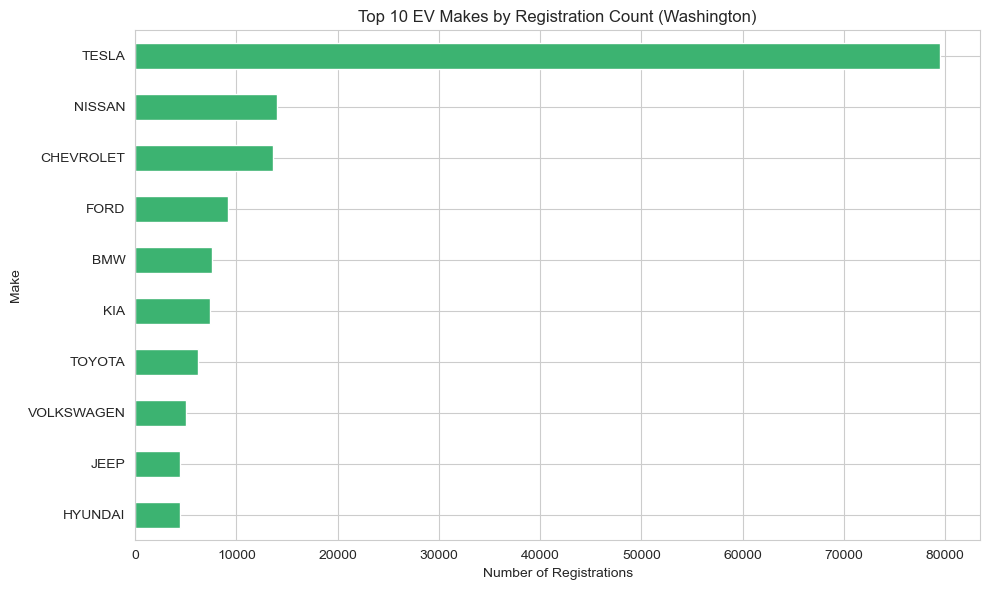

In [55]:
# top makes
plt.figure(figsize=(10, 6))
top_makes.sort_values().plot(kind='barh', color='mediumseagreen')
plt.title("Top 10 EV Makes by Registration Count (Washington)")
plt.xlabel("Number of Registrations")
plt.ylabel("Make")
plt.tight_layout()
plt.savefig("top_makes.png")
plt.show()

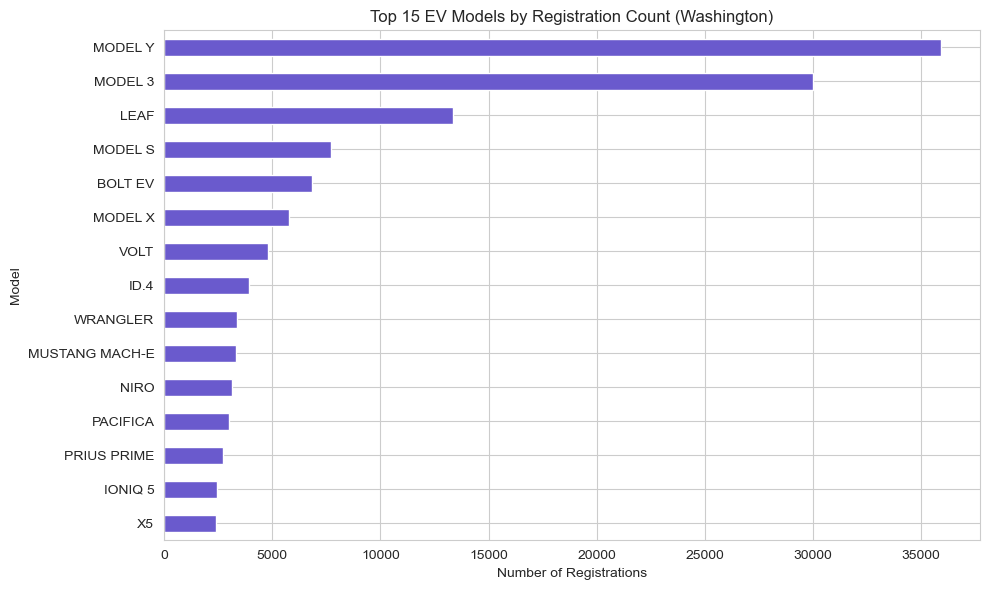

In [56]:
# top models
plt.figure(figsize=(10, 6))
top_models.sort_values().plot(kind='barh', color='slateblue')
plt.title("Top 15 EV Models by Registration Count (Washington)")
plt.xlabel("Number of Registrations")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("top_models.png")
plt.show()

### Part B: Cross-tab with Electric Vehicle Type (BEV vs PHEV)

In [57]:
# Overall BEV vs PHEV split
type_counts = df_wa['Electric Vehicle Type'].value_counts()
print("Overall EV Type Split:")
print(type_counts)

Overall EV Type Split:
Electric Vehicle Type
Battery Electric Vehicle (BEV)            138948
Plug-in Hybrid Electric Vehicle (PHEV)     38529
Name: count, dtype: int64


In [58]:
type_share = (df_wa['Electric Vehicle Type'].value_counts(normalize=True) * 100).round(2)
print("\nEV Type Market Share (%):")
print(type_share)


EV Type Market Share (%):
Electric Vehicle Type
Battery Electric Vehicle (BEV)            78.29
Plug-in Hybrid Electric Vehicle (PHEV)    21.71
Name: proportion, dtype: float64


In [59]:
# top 10 makes %
top_10_makes_list = df_wa['Make'].value_counts().head(10).index

make_type_breakdown = pd.crosstab(
    df_wa[df_wa['Make'].isin(top_10_makes_list)]['Make'],
    df_wa[df_wa['Make'].isin(top_10_makes_list)]['Electric Vehicle Type'],
    normalize='index'
) * 100

print("\nBEV vs PHEV Breakdown (%) for Top 10 Makes:")
print(make_type_breakdown.round(2))


BEV vs PHEV Breakdown (%) for Top 10 Makes:
Electric Vehicle Type  Battery Electric Vehicle (BEV)  \
Make                                                    
BMW                                             33.23   
CHEVROLET                                       64.97   
FORD                                            60.03   
HYUNDAI                                         85.72   
JEEP                                             0.00   
KIA                                             67.84   
NISSAN                                         100.00   
TESLA                                          100.00   
TOYOTA                                           5.37   
VOLKSWAGEN                                     100.00   

Electric Vehicle Type  Plug-in Hybrid Electric Vehicle (PHEV)  
Make                                                           
BMW                                                     66.77  
CHEVROLET                                               35.03  
FORD          

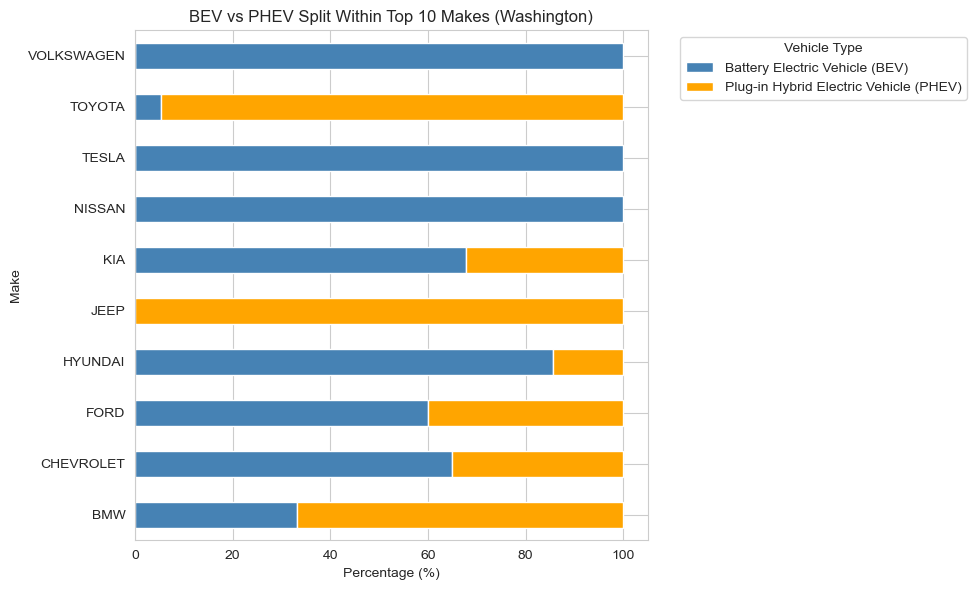

In [60]:
# Visualize as a stacked bar chart 
make_type_breakdown.plot(kind='barh', stacked=True, figsize=(10, 6),
                          color=['steelblue', 'orange'])
plt.title("BEV vs PHEV Split Within Top 10 Makes (Washington)")
plt.xlabel("Percentage (%)")
plt.ylabel("Make")
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("bev_phev_by_make.png")
plt.show()

# Phase 6: EV Types and Technology Analysis
### Part A: Range evolution over time, by vehicle type

In [61]:
df_range = df_wa[df_wa['Range Reported'] == 'Reported'].copy()
print(f"Rows with reported range: {len(df_range)} out of {len(df_wa)}")


Rows with reported range: 85686 out of 177477


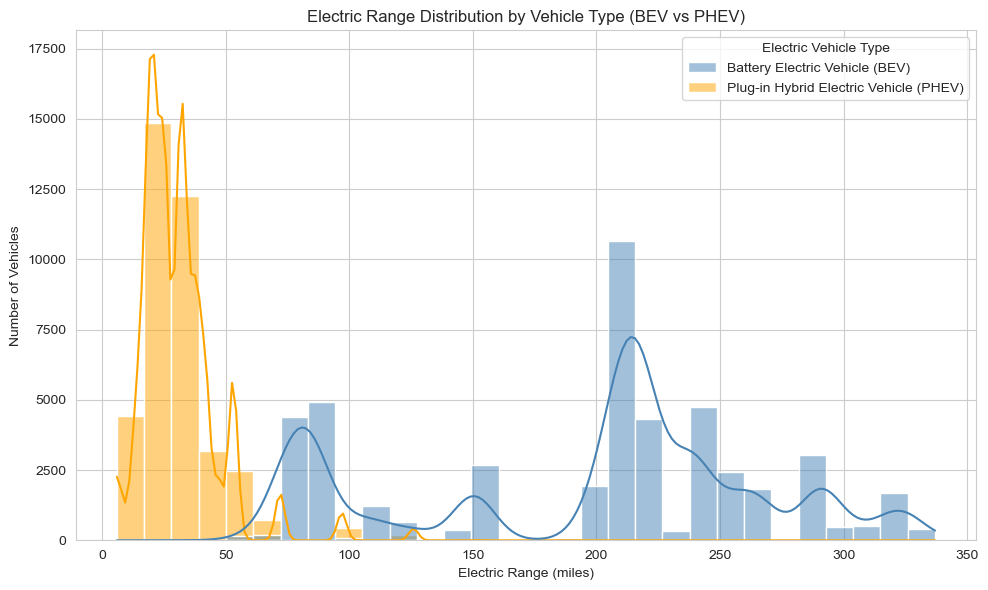

In [62]:
# Re-plot the range histogram, but split by BEV vs PHEV this time 
plt.figure(figsize=(10, 6))
sns.histplot(data=df_range, x='Electric Range', hue='Electric Vehicle Type',
             bins=30, kde=True, palette=['steelblue', 'orange'])
plt.title("Electric Range Distribution by Vehicle Type (BEV vs PHEV)")
plt.xlabel("Electric Range (miles)")
plt.ylabel("Number of Vehicles")
plt.tight_layout()
plt.savefig("range_by_vehicle_type.png")
plt.show()

In [63]:
# Average range by Model Year, split by vehicle type 
range_by_year_type = df_range.groupby(['Model Year', 'Electric Vehicle Type'])['Electric Range'].mean().reset_index()
print("\nAverage Range by Model Year and Vehicle Type:")
print(range_by_year_type)


Average Range by Model Year and Vehicle Type:
    Model Year                   Electric Vehicle Type  Electric Range
0         1997          Battery Electric Vehicle (BEV)       39.000000
1         1998          Battery Electric Vehicle (BEV)       58.000000
2         1999          Battery Electric Vehicle (BEV)       74.000000
3         2000          Battery Electric Vehicle (BEV)       58.000000
4         2002          Battery Electric Vehicle (BEV)       95.000000
5         2003          Battery Electric Vehicle (BEV)       95.000000
6         2008          Battery Electric Vehicle (BEV)      220.000000
7         2010          Battery Electric Vehicle (BEV)      245.000000
8         2010  Plug-in Hybrid Electric Vehicle (PHEV)      100.000000
9         2011          Battery Electric Vehicle (BEV)       74.793991
10        2011  Plug-in Hybrid Electric Vehicle (PHEV)       35.000000
11        2012          Battery Electric Vehicle (BEV)      105.046235
12        2012  Plug-in Hybrid

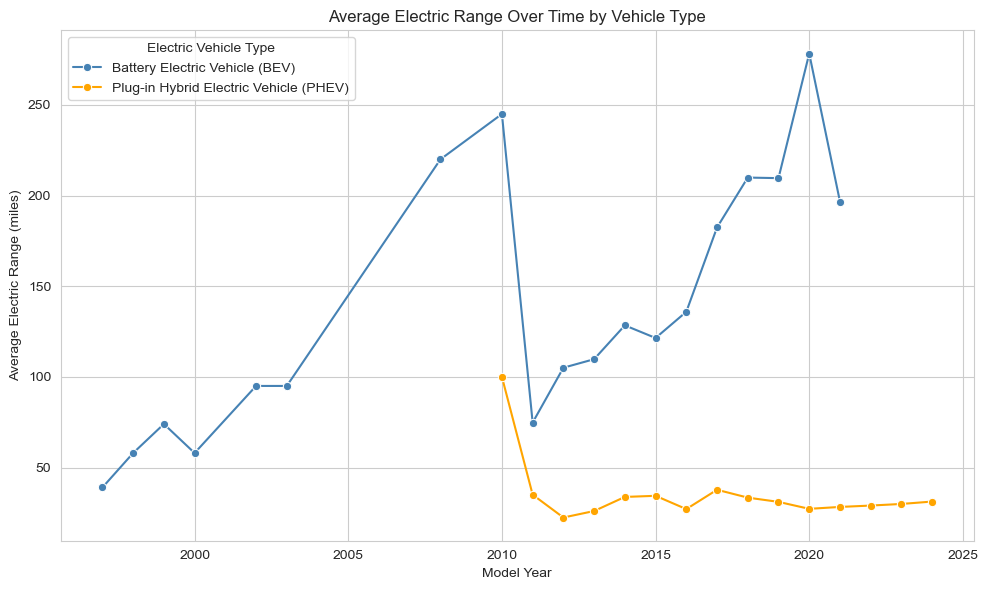

In [64]:
# Visualize range progression over time 
plt.figure(figsize=(10, 6))
sns.lineplot(data=range_by_year_type, x='Model Year', y='Electric Range',
             hue='Electric Vehicle Type', marker='o', palette=['steelblue', 'orange'])
plt.title("Average Electric Range Over Time by Vehicle Type")
plt.xlabel("Model Year")
plt.ylabel("Average Electric Range (miles)")
plt.tight_layout()
plt.savefig("range_progression_by_type.png")
plt.show()

In [65]:
#Quantify the reporting gap for recent BEVs
recent_bev = df_wa[(df_wa['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)') &
                    (df_wa['Model Year'] >= 2020)]

reporting_gap = recent_bev.groupby('Model Year')['Range Reported'].value_counts(normalize=True).unstack() * 100
print("BEV Range Reporting Rate by Model Year (2020+):")
print(reporting_gap.round(1))

BEV Range Reporting Rate by Model Year (2020+):
Range Reported  Reported  Unknown
Model Year                       
2020                99.4      0.6
2021                 3.7     96.3
2022                 NaN    100.0
2023                 NaN    100.0
2024                 NaN    100.0


### Part B: Range vs Base MSRP correlation

In [66]:
# BOTH range is reported AND MSRP is non-zero
df_corr = df_wa[(df_wa['Range Reported'] == 'Reported') & (df_wa['Base MSRP'] > 0)].copy()
print(f"Rows usable for Range vs MSRP correlation: {len(df_corr)} out of {len(df_wa)}")

Rows usable for Range vs MSRP correlation: 3331 out of 177477


In [67]:
# correlation coefficient ---
correlation = df_corr['Electric Range'].corr(df_corr['Base MSRP'])
print(f"\nCorrelation between Electric Range and Base MSRP: {correlation:.3f}")


Correlation between Electric Range and Base MSRP: 0.407


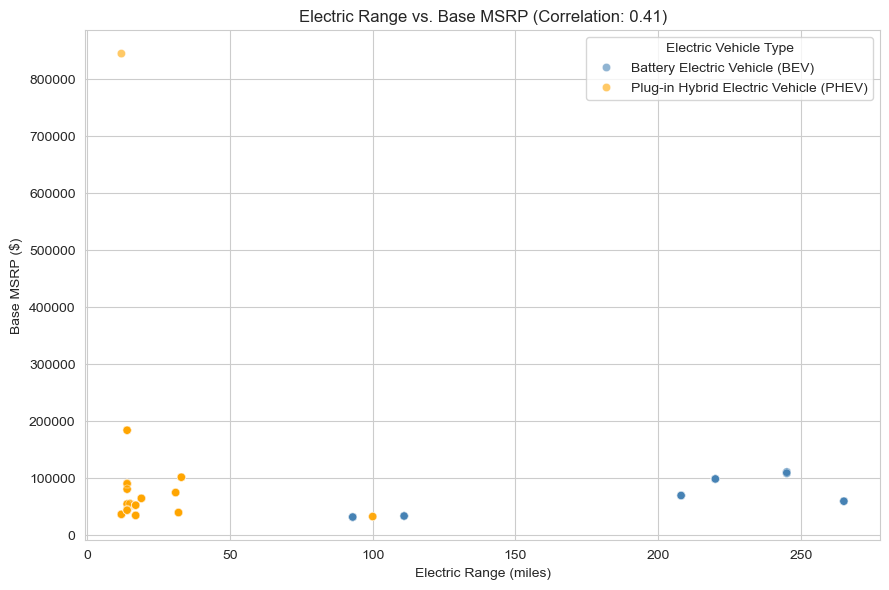

In [68]:
# Scatter plot to visualize the relationship ---
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_corr, x='Electric Range', y='Base MSRP',
                 hue='Electric Vehicle Type', alpha=0.6, palette=['steelblue', 'orange'])
plt.title(f"Electric Range vs. Base MSRP (Correlation: {correlation:.2f})")
plt.xlabel("Electric Range (miles)")
plt.ylabel("Base MSRP ($)")
plt.tight_layout()
plt.savefig("range_vs_msrp.png")
plt.show()

In [69]:
# outlier(s)
outlier_check = df_corr[df_corr['Base MSRP'] > 500000]
print("Outlier row(s):")
print(outlier_check[['Make', 'Model', 'Model Year', 'Electric Range', 'Base MSRP']])

Outlier row(s):
          Make Model  Model Year  Electric Range  Base MSRP
63677  PORSCHE   918        2015              12     845000


In [70]:
# Recalculate correlation excluding this outlier
df_corr_no_outlier = df_corr[df_corr['Base MSRP'] <= 500000]
correlation_no_outlier = df_corr_no_outlier['Electric Range'].corr(df_corr_no_outlier['Base MSRP'])
print(f"\nCorrelation without extreme outlier: {correlation_no_outlier:.3f}")
print(f"Rows used: {len(df_corr_no_outlier)}")


Correlation without extreme outlier: 0.524
Rows used: 3330


# Phase 7: Forecasting
### Part A: Simple Linear Regression

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [72]:
# Filter to our reliable training window: 2011-2023 
train_df = yearly_df[(yearly_df['Model Year'] >= 2011) & (yearly_df['Model Year'] <= 2023)].copy()
print("Training data (2011-2023):")
print(train_df)

Training data (2011-2023):
    Model Year  Registrations  YoY Growth (%)  Cumulative Registrations
8         2011            775     3269.565217                       834
9         2012           1618      108.774194                      2452
10        2013           4408      172.435105                      6860
11        2014           3509      -20.394737                     10369
12        2015           4844       38.045027                     15213
13        2016           5483       13.191577                     20696
14        2017           8561       56.137151                     29257
15        2018          14322       67.293540                     43579
16        2019          10939      -23.621003                     54518
17        2020          11768        7.578389                     66286
18        2021          19132       62.576479                     85418
19        2022          27776       45.180849                    113194
20        2023          57587      10

In [73]:
X = train_df[['Model Year']] 
y = train_df['Registrations']

In [74]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [75]:
y_pred_train = model.predict(X)
r2 = r2_score(y, y_pred_train)
mae = mean_absolute_error(y, y_pred_train)

In [76]:
print(f"\nModel R² score: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.0f} vehicles")
print(f"Slope (yearly increase): {model.coef_[0]:.1f} vehicles/year")
print(f"Intercept: {model.intercept_:.1f}")


Model R² score: 0.643
Mean Absolute Error: 6209 vehicles
Slope (yearly increase): 3166.8 vehicles/year
Intercept: -6374374.1


In [77]:
# Forecast for 2024, 2025, 2026
future_years = pd.DataFrame({'Model Year': [2024, 2025, 2026]})
future_predictions = model.predict(future_years)

forecast_df = future_years.copy()
forecast_df['Predicted Registrations'] = future_predictions.round(0)
print("\nForecast for 2024-2026:")
print(forecast_df)


Forecast for 2024-2026:
   Model Year  Predicted Registrations
0        2024                  35300.0
1        2025                  38467.0
2        2026                  41634.0


In [78]:
# Visualize actual vs. predicted vs. forecast
# Actual historical data (2011-2023)
plt.plot(train_df['Model Year'], train_df['Registrations'],
         marker='o', color='steelblue', label='Actual Registrations (2011-2023)')

# Linear regression fit line over the training years
plt.plot(train_df['Model Year'], y_pred_train,
         linestyle='--', color='green', label='Linear Regression Fit')

# Forecast for 2024-2026
plt.plot(forecast_df['Model Year'], forecast_df['Predicted Registrations'],
         marker='X', markersize=10, color='red', linestyle='--', label='Forecast (2024-2026)')

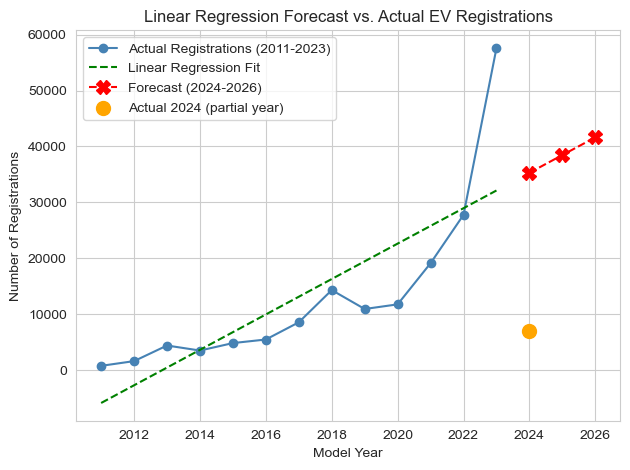

In [79]:
actual_2024 = yearly_df[yearly_df['Model Year'] == 2024]['Registrations'].values[0]
plt.scatter(2024, actual_2024, color='orange', s=100, zorder=5,
            label='Actual 2024 (partial year)')
plt.title("Linear Regression Forecast vs. Actual EV Registrations")
plt.xlabel("Model Year")
plt.ylabel("Number of Registrations")
plt.legend()
plt.tight_layout()
plt.savefig("linear_regression_forecast.png")
plt.show()

### Part B: ARIMA

In [80]:
from statsmodels.tsa.arima.model import ARIMA

In [81]:
train_df = yearly_df[(yearly_df['Model Year'] >= 2011) & (yearly_df['Model Year'] <= 2023)].copy()
train_df = train_df.set_index('Model Year')

In [82]:
print("Training series (2011-2023):")
print(train_df)

Training series (2011-2023):
            Registrations  YoY Growth (%)  Cumulative Registrations
Model Year                                                         
2011                  775     3269.565217                       834
2012                 1618      108.774194                      2452
2013                 4408      172.435105                      6860
2014                 3509      -20.394737                     10369
2015                 4844       38.045027                     15213
2016                 5483       13.191577                     20696
2017                 8561       56.137151                     29257
2018                14322       67.293540                     43579
2019                10939      -23.621003                     54518
2020                11768        7.578389                     66286
2021                19132       62.576479                     85418
2022                27776       45.180849                    113194
2023               

In [83]:
model_arima = ARIMA(train_df['Registrations'], order=(1, 1, 1))
model_fit = model_arima.fit()

C:\Users\vaibh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\vaibh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\vaibh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\vaibh\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters

In [84]:
print("\nARIMA Model Summary:")
print(model_fit.summary())


ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:          Registrations   No. Observations:                   13
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -123.691
Date:                Thu, 16 Jul 2026   AIC                            253.382
Time:                        12:33:23   BIC                            254.837
Sample:                             0   HQIC                           252.843
                                 - 13                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.369      2.706      0.007       0.276       1.724
ma.L1         -0.0298      1.144     -0.026      0.979      -2.273       2.213
sigma2      5.118e+07   2.01e-

In [85]:
# Forecast next 3 years ---
forecast_result = model_fit.get_forecast(steps=3)
forecast_values = forecast_result.predicted_mean
confidence_intervals = forecast_result.conf_int()

forecast_years = [2024, 2025, 2026]
arima_forecast_df = pd.DataFrame({
    'Model Year': forecast_years,
    'Predicted Registrations': forecast_values.values.round(0),
    'Lower CI': confidence_intervals.iloc[:, 0].values.round(0),
    'Upper CI': confidence_intervals.iloc[:, 1].values.round(0)
})

print("\nARIMA Forecast for 2024-2026:")
print(arima_forecast_df)


ARIMA Forecast for 2024-2026:
   Model Year  Predicted Registrations  Lower CI  Upper CI
0        2024                  86766.0   72745.0  100787.0
1        2025                 115945.0   84966.0  146925.0
2        2026                 145124.0   93554.0  196694.0


C:\Users\vaibh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\vaibh\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### Part C: Compare Linear Regression vs ARIMA

In [86]:
# historical data
plt.plot(train_df.index, train_df['Registrations'],
         marker='o', color='steelblue', label='Actual Registrations (2011-2023)')

# Linear regression forecast
plt.plot(forecast_df['Model Year'], forecast_df['Predicted Registrations'],
         marker='X', markersize=10, color='green', linestyle='--',
         label='Linear Regression Forecast')

# ARIMA forecast
plt.plot(arima_forecast_df['Model Year'], arima_forecast_df['Predicted Registrations'],
         marker='X', markersize=10, color='red', linestyle='--',
         label='ARIMA Forecast')
plt.fill_between(arima_forecast_df['Model Year'],
                  arima_forecast_df['Lower CI'], arima_forecast_df['Upper CI'],
                  color='red', alpha=0.15, label='ARIMA 95% Confidence Interval')

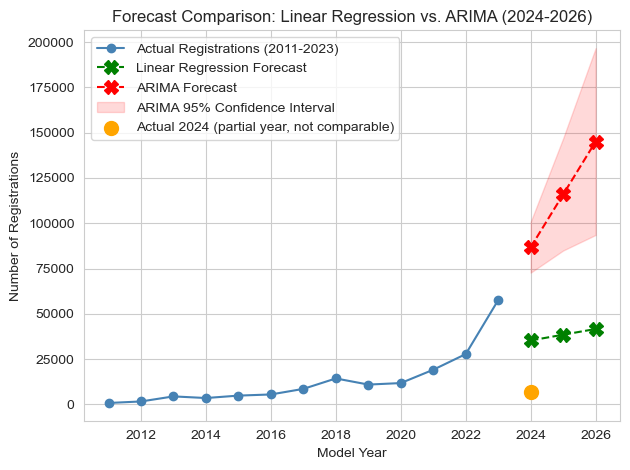

In [87]:
actual_2024 = yearly_df[yearly_df['Model Year'] == 2024]['Registrations'].values[0]
plt.scatter(2024, actual_2024, color='orange', s=100, zorder=5,
            label='Actual 2024 (partial year, not comparable)')

plt.title("Forecast Comparison: Linear Regression vs. ARIMA (2024-2026)")
plt.xlabel("Model Year")
plt.ylabel("Number of Registrations")
plt.legend()
plt.tight_layout()
plt.savefig("forecast_comparison.png")
plt.show()

# Phase 8: Correlation and Trend Analysis
### Part A: Correlation Matrix

In [88]:
numerical_cols = ['Model Year', 'Electric Range', 'Base MSRP', 'Latitude', 'Longitude']
df_numeric = df_wa[numerical_cols].copy()

In [89]:
df_numeric_filtered = df_wa[df_wa['Range Reported'] == 'Reported'][numerical_cols].copy()

print(f"Rows used for correlation matrix: {len(df_numeric_filtered)} out of {len(df_wa)}")

Rows used for correlation matrix: 85686 out of 177477


In [90]:
# correlation matrix ---
corr_matrix = df_numeric_filtered.corr()
print("\nCorrelation Matrix:")
print(corr_matrix.round(3))


Correlation Matrix:
                Model Year  Electric Range  Base MSRP  Latitude  Longitude
Model Year           1.000          -0.060     -0.199    -0.036      0.019
Electric Range      -0.060           1.000      0.027     0.039     -0.020
Base MSRP           -0.199           0.027      1.000     0.010     -0.006
Latitude            -0.036           0.039      0.010     1.000     -0.045
Longitude            0.019          -0.020     -0.006    -0.045      1.000


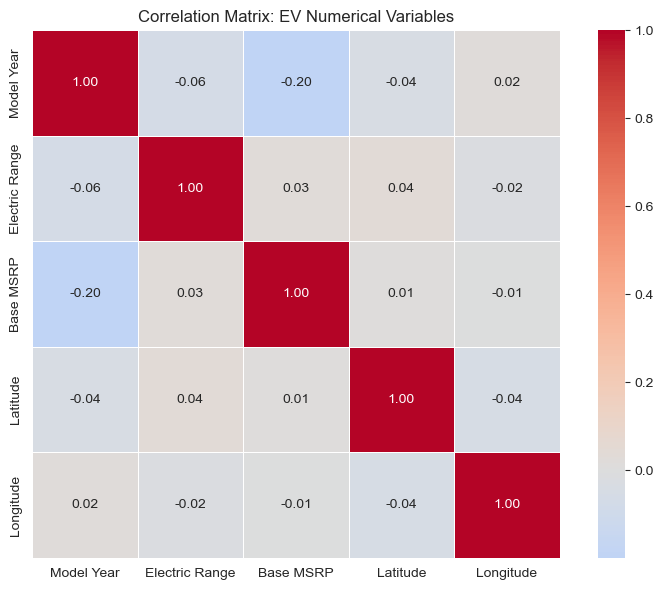

In [91]:
# Visualize as a heatmap 
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Matrix: EV Numerical Variables")
plt.tight_layout()
plt.savefig("correlation_matrix_heatmap.png")
plt.show()